<a href="https://colab.research.google.com/github/Magistrate-dot/ML-AI-project-_Minecraft_Object_Detection/blob/main/Minecraft_Mob_Detection_model_Comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prep

In [1]:
!pip install -q ultralytics huggingface_hub scikit-learn
import os
import json
import shutil
from collections import defaultdict
from sklearn.model_selection import train_test_split

from huggingface_hub import snapshot_download
DATASET_PATH = "/content/minecraft_dataset"

repo_dir = snapshot_download(
    repo_id="twoturtles/minecraft-mobs",
    repo_type="dataset"
)

print(repo_dir)

!wget -O test_image.jpg "https://raw.githubusercontent.com/Magistrate-dot/ML-AI-project/main/Test_mob.jpg"

for split in ["train", "valid"]:
    os.makedirs(f"{DATASET_PATH}/{split}/images", exist_ok=True)
    os.makedirs(f"{DATASET_PATH}/{split}/labels", exist_ok=True)

with open(os.path.join(repo_dir, "annotations.json"), "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

annotations_by_image = defaultdict(list)

for ann in annotations:
    annotations_by_image[ann["image_id"]].append(ann)

train_images, valid_images = train_test_split(
    images,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training images:", len(train_images))
print("Validation images:", len(valid_images))

def process_split(image_list, split_name):

    for img in image_list:

        image_id = img["id"]
        filename = img["file_name"]

        src = os.path.join(repo_dir, "images", filename)
        dst = os.path.join(DATASET_PATH, split_name, "images", filename)

        shutil.copy(src, dst)

        label_file = os.path.join(
            DATASET_PATH,
            split_name,
            "labels",
            filename.replace(".png", ".txt")
        )

        with open(label_file, "w") as f:

            for ann in annotations_by_image.get(image_id, []):

                x, y, w, h = ann["bbox"]

                xc = (x + w / 2) / img["width"]
                yc = (y + h / 2) / img["height"]
                wn = w / img["width"]
                hn = h / img["height"]

                cls = ann["category_id"]

                f.write(
                    f"{cls} {xc} {yc} {wn} {hn}\n"
                )
process_split(train_images, "train")
process_split(valid_images, "valid")

yaml_text = f"""
path: {DATASET_PATH}

train: train/images
val: valid/images

names:
  0: chicken
  1: cow
  2: creeper
  3: enderman
  4: pig
  5: sheep
  6: skeleton
  7: spider
  8: zombie
"""

with open("data.yaml", "w") as f:
    f.write(yaml_text)

print("Train images:", len(os.listdir(f"{DATASET_PATH}/train/images")))
print("Train labels:", len(os.listdir(f"{DATASET_PATH}/train/labels")))

print("Validation images:", len(os.listdir(f"{DATASET_PATH}/valid/images")))
print("Validation labels:", len(os.listdir(f"{DATASET_PATH}/valid/labels")))



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 411 files:   0%|          | 0/411 [00:00<?, ?it/s]

/root/.cache/huggingface/hub/datasets--twoturtles--minecraft-mobs/snapshots/a692d651805beaa37972f673ce93f4ef4b8c6394
--2026-06-17 14:42:29--  https://raw.githubusercontent.com/Magistrate-dot/ML-AI-project/main/Test_mob.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22571 (22K) [image/jpeg]
Saving to: ‘test_image.jpg’

test_image.jpg      100%[===================>]  22.04K  --.-KB/s    in 0.001s  

2026-06-17 14:42:29 (14.9 MB/s) - ‘test_image.jpg’ saved [22571/22571]

Training images: 326
Validation images: 82
Train images: 326
Train labels: 326
Validation images: 82
Validation labels: 82


In [5]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# Count annotations per class
class_counts = Counter()

for ann in annotations:
    class_counts[ann["category_id"]] += 1

# Class neames
class_names = {
    0: "chicken",
    1: "cow",
    2: "creeper",
    3: "enderman",
    4: "pig",
    5: "sheep",
    6: "skeleton",
    7: "spider",
    8: "zombie"
}

# Create DataFrame
df_classes = pd.DataFrame({
    "Class": [class_names[i] for i in sorted(class_counts.keys())],
    "Annotations": [class_counts[i] for i in sorted(class_counts.keys())]
})

print(df_classes)

      Class  Annotations
0   chicken           62
1       cow           64
2   creeper           58
3  enderman           50
4       pig           62
5     sheep           47
6  skeleton           48
7    spider           57
8    zombie           55


# Model

In [6]:
from ultralytics import YOLO

nano = YOLO("yolo11n.pt")
nano.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
)

small = YOLO("yolo11s.pt")
small.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fba3b18e510>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

# Analytics

Extracting final metrics and training history...
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,907 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2792.8±502.7 MB/s, size: 216.6 KB)
val: Scanning /content/minecraft_dataset/valid/labels.cache... 82 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 17.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.7s
                   all         82        104      0.951      0.933      0.979      0.795
               chicken         14         16      0.932      0.938      0.979      0.757
                   cow         10         12          1      0.938      0.995      0.804
               creeper          8          8      0.849          1      0.995      0.887
              enderman         10         10      0.934        0.9      0.978   

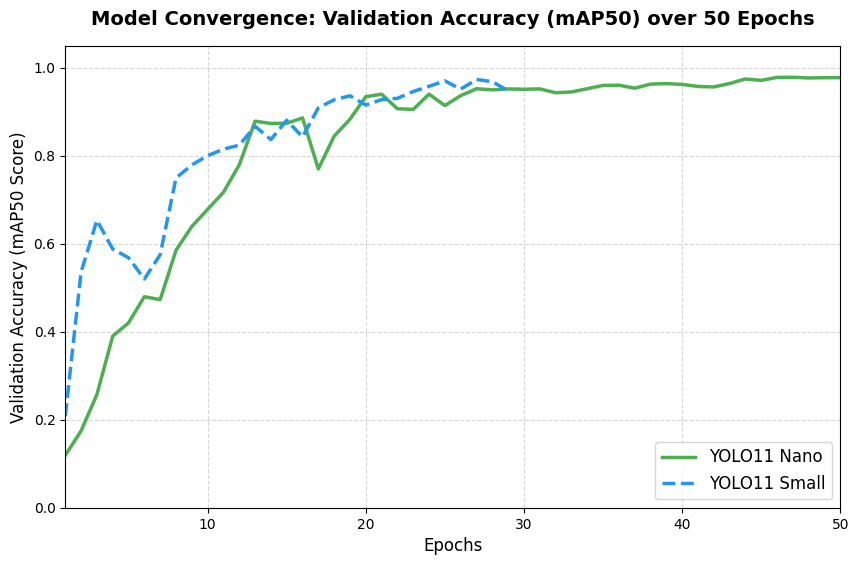


 Line graph generated successfully as 'model_accuracy_line_graph.png'!


<Figure size 640x480 with 0 Axes>

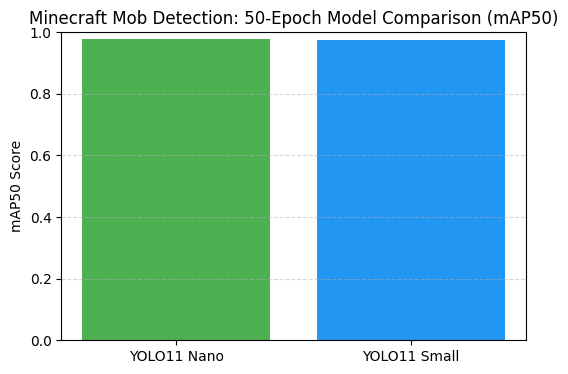

In [7]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Extracting final metrics and training history...")

# 1. Grab final validation metrics (keeps your terminal printout working!)
nano_metrics = YOLO("/content/runs/detect/train/weights/best.pt").val(split="val")
small_metrics = YOLO("/content/runs/detect/train-2/weights/best.pt").val(split="val")

# Generate and print the data frame summary
comparison = pd.DataFrame({
    "Model": ["YOLO11 Nano", "YOLO11 Small"],
    "Precision": [nano_metrics.box.mp, small_metrics.box.mp],
    "Recall": [nano_metrics.box.mr, small_metrics.box.mr],
    "mAP50": [nano_metrics.box.map50, small_metrics.box.map50],
    "mAP50-95": [nano_metrics.box.map, small_metrics.box.map]
})

print("\n=== FINAL MODEL PERFORMANCE COMPARISON ===")
print(comparison)
comparison.to_csv("final_50_epoch_comparison.csv", index=False)


# create line graph
nano_csv_path = "/content/runs/detect/train/results.csv"
small_csv_path = "/content/runs/detect/train-2/results.csv"

if os.path.exists(nano_csv_path) and os.path.exists(small_csv_path):
    # Load history files
    df_nano = pd.read_csv(nano_csv_path)
    df_small = pd.read_csv(small_csv_path)

    # Clean up column names
    df_nano.columns = df_nano.columns.str.strip()
    df_small.columns = df_small.columns.str.strip()

    # Set up the line graph layout
    plt.figure(figsize=(10, 6))

    # Plot Nano Curve (Solid Green Line)
    plt.plot(df_nano['epoch'], df_nano['metrics/mAP50(B)'],
             label='YOLO11 Nano', color='#4CAF50', linewidth=2.5, linestyle='-')

    # Plot Small Curve (Dashed Blue Line)
    plt.plot(df_small['epoch'], df_small['metrics/mAP50(B)'],
             label='YOLO11 Small', color='#2196F3', linewidth=2.5, linestyle='--')

    # Style the graph
    plt.title("Model Convergence: Validation Accuracy (mAP50) over 50 Epochs", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Validation Accuracy (mAP50 Score)", fontsize=12)

    plt.xlim(1, 50)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=12, loc='lower right')
    plt.show() # Display the line graph

    # Save a file for downloading
    plt.savefig("model_accuracy_line_graph.png", dpi=300, bbox_inches='tight')
    print("\n Line graph generated successfully as 'model_accuracy_line_graph.png'!")
else:
    print("\n Error: Could not find 'results.csv' in /train/ or /train-2/ folders.")

# Plot the mAP50 performance side-by-side
plt.figure(figsize=(6, 4))
plt.bar(comparison["Model"], comparison["mAP50"], color=['#4CAF50', '#2196F3'])
plt.title("Minecraft Mob Detection: 50-Epoch Model Comparison (mAP50)")
plt.ylabel("mAP50 Score")
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Test

Analyzing 'test_image.jpg' for Minecraft mobs with both models...

image 1/1 /content/test_image.jpg: 640x640 1 creeper, 15.5ms
Speed: 2.8ms preprocess, 15.5ms inference, 4.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

🎉 DETECTION COMPLETE (YOLO11 Small)! Here is what the Small AI found:


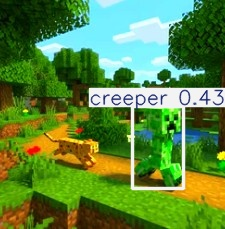


image 1/1 /content/test_image.jpg: 640x640 (no detections), 7.8ms
Speed: 2.2ms preprocess, 7.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2

🎉 DETECTION COMPLETE (YOLO11 Nano)! Here is what the Nano AI found:


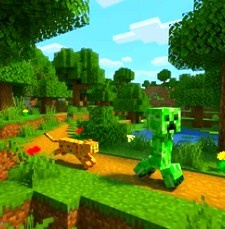

In [8]:
import os
from ultralytics import YOLO
from IPython.display import Image, display

# 1. Path to your uploaded JPG image inside the content folder
image_path = "/content/test_image.jpg"

# Load both models with clear names using their correct save paths
small_model = YOLO("/content/runs/detect/train-2/weights/best.pt")
nano_model  = YOLO("/content/runs/detect/train/weights/best.pt")

print(f"Analyzing '{os.path.basename(image_path)}' for Minecraft mobs with both models...")

# Run prediction with the small_model and save visually
results_small = small_model.predict(source=image_path, conf=0.25, save=True)

# Grab the output paths dynamically for the small model
saved_dir_small = results_small[0].save_dir
base_name_small = os.path.basename(results_small[0].path)
output_visual_path_small = os.path.join(saved_dir_small, base_name_small)

print("\n🎉 DETECTION COMPLETE (YOLO11 Small)! Here is what the Small AI found:")
display(Image(filename=output_visual_path_small))

# Run prediction with the nano_model and save visually
results_nano = nano_model.predict(source=image_path, conf=0.25, save=True)

# Grab the output paths dynamically for the nano model
saved_dir_nano = results_nano[0].save_dir
base_name_nano = os.path.basename(results_nano[0].path)
output_visual_path_nano = os.path.join(saved_dir_nano, base_name_nano)

print("\n🎉 DETECTION COMPLETE (YOLO11 Nano)! Here is what the Nano AI found:")
display(Image(filename=output_visual_path_nano))